AGENDA
1. objetivo de estudio
2. Exploraciones de datos EDA
3. Limpieza de datos
4. Entrenar el modelo (árbol de decisión)
5. Evaluar el modelo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

#OBJETIVO

crear y evaluar un modelo de árbol de decisión para predecir las ventas con datos simulados de una empresa, dependiendo de las inversiones realizadas en publicidad

In [ ]:
datos = pd.read_csv("https://raw.githubusercontent.com/rpizarrog/Analisis-Inteligente-de-datos/main/datos/Advertising_Web.csv")
datos.head

<bound method NDFrame.head of      Unnamed: 0    X     TV  Radio  Newspaper         Web  Sales
0             1    1  230.1   37.8       69.2  306.634752   22.1
1             2    2   44.5   39.3       45.1  302.653070   10.4
2             3    3   17.2   45.9       69.3   49.498908    9.3
3             4    4  151.5   41.3       58.5  257.816893   18.5
4             5    5  180.8   10.8       58.4  195.660076   12.9
..          ...  ...    ...    ...        ...         ...    ...
195         196  196   38.2    3.7       13.8  248.841073    7.6
196         197  197   94.2    4.9        8.1  118.041856    9.7
197         198  198  177.0    9.3        6.4  213.274671   12.8
198         199  199  283.6   42.0       66.2  237.498063   25.5
199         200  200  232.1    8.6        8.7  151.990733   13.4

[200 rows x 7 columns]>

Text(0.5, 1.0, 'Web vs Ventas')

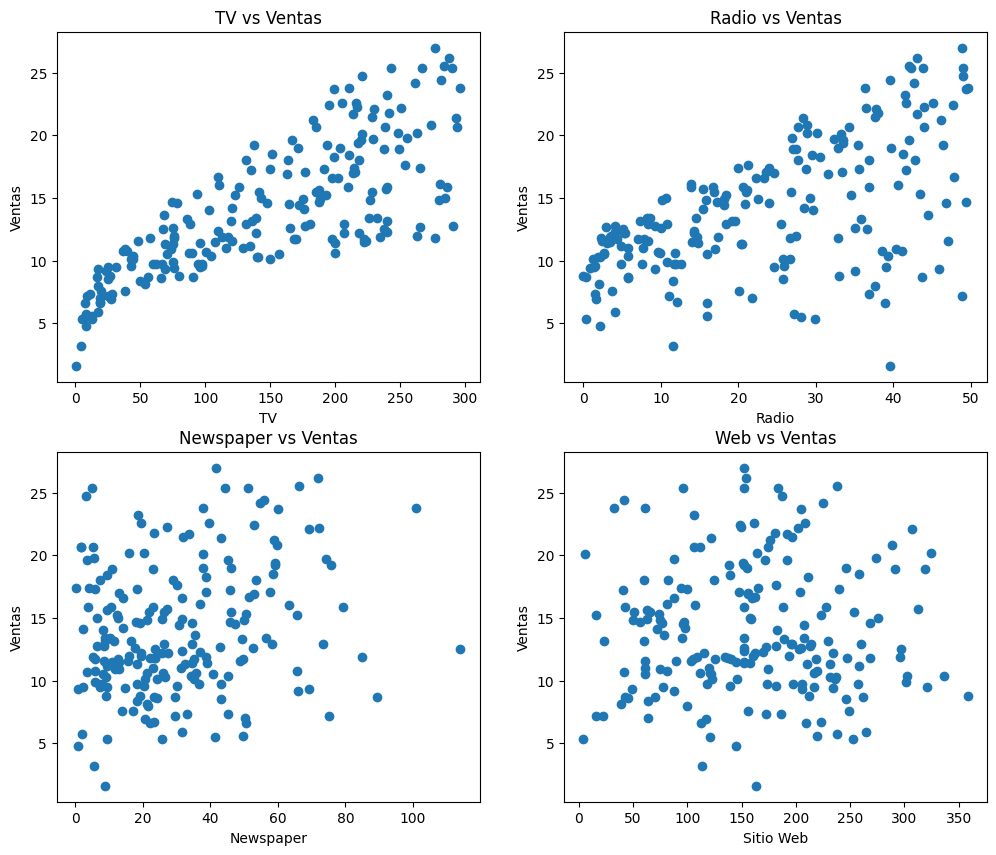

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,10))

axes[0,0].scatter(datos["TV"],datos["Sales"])
axes[0,0].set_xlabel("TV")
axes[0,0].set_ylabel("Ventas")
axes[0,0].set_title("TV vs Ventas")

axes[0,1].scatter(datos["Radio"],datos["Sales"])
axes[0,1].set_xlabel("Radio")
axes[0,1].set_ylabel("Ventas")
axes[0,1].set_title("Radio vs Ventas")

axes[1,0].scatter(datos["Newspaper"],datos["Sales"])
axes[1,0].set_xlabel("Newspaper")
axes[1,0].set_ylabel("Ventas")
axes[1,0].set_title("Newspaper vs Ventas")

axes[1,1].scatter(datos["Web"],datos["Sales"])
axes[1,1].set_xlabel("Sitio Web")
axes[1,1].set_ylabel("Ventas")
axes[1,1].set_title("Web vs Ventas")


In [ ]:
print("Observaciones y variables: ",datos.shape)

Observaciones y variables:  (200, 7)


In [ ]:
datos.dtypes

,0
Unnamed: 0,int64
X,int64
TV,float64
Radio,float64
Newspaper,float64
Web,float64
Sales,float64


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   X           200 non-null    int64  
 2   TV          200 non-null    float64
 3   Radio       200 non-null    float64
 4   Newspaper   200 non-null    float64
 5   Web         200 non-null    float64
 6   Sales       200 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 11.1 KB


Se describen como variables independientes TV,Radio, Newspaper y Web y como variable dependiente Sales.

Las variables independientes son:
* TV: costos de publicidad en TV (miles de dólares).
* Radio: costos de publicidad inertidos en medios de difusión radio (miles de dólares).
* Newspaper: costos publicitarios para medios impresos (miles de dólares).
* Web: costos publicitarios en herramientas digitales (miles de dólares).

In [ ]:
datos.head()

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9


3. Limpieza de datos

In [ ]:
datos = datos[["TV","Radio","Newspaper","Web","Sales"]]
datos.describe()

,TV,Radio,Newspaper,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,159.587355,14.022500
std,85.854236,14.846809,21.778621,76.815266,5.217457
min,0.700000,0.000000,0.300000,4.308085,1.600000
25%,74.375000,9.975000,12.750000,99.048767,10.375000
50%,149.750000,22.900000,25.750000,156.862154,12.900000
75%,218.825000,36.525000,45.100000,212.311848,17.400000
max,296.400000,49.600000,114.000000,358.247042,27.000000


##4. Datos de entrenamiento y datos de validación
(Entrenamiento de modelo)

se empleará la semilla 1279 (random_state-2022) Los datos se distribuirán de la siguiente manera:

70% para entrenamiento
30% para validación de modelo

In [ ]:
X_entrenamiento, X_validacion, Y_entrena, Y_validacion = train_test_split(datos.drop(columns="Sales"),datos["Sales"],train_size=.7,random_state=1279)

In [ ]:
print("Estrcutura de datos de entrenamiento: ",X_entrenamiento.shape)

Estrcutura de datos de entrenamiento:  (140, 4)


$$4.1 MODELANDO EL ÁRBOL DE DECISIÓN
La clase DecisionTreeRegressor del módulo sklearn.tree tiene
los siguientes parámetros:
* max_depth: profundidad máxima que puede alcanzar el árbol.
* min_samples_split: número mínimo de observaciones que debe detener el nodo para que pueda dividirse. Si es un valor decimal se interpreta como la fracción total de observaciones de entrenamiento ceil(min_samples_split*n_samples).
* min_samples_leaf: número mínimo de observaciones que debe tener cada uno de los nodos hijos para que se produzca la división.
* max_leaf_nodes: número máximo de nodos terminales
* random_seed: semilla que permite resultados reproducibles.Es un valor entero.

In [ ]:
modelo_ar=DecisionTreeRegressor(max_depth=3,random_state=2022)

In [ ]:
modelo_ar.fit(X_entrenamiento,Y_entrena)

DecisionTreeRegressor(max_depth=3, random_state=2022)

##4.2 VISUALIZACION DEL MODELO

In [ ]:
print(f"Profundidad del árbol: {modelo_ar.get_depth()}")
print(f"Número de nodos terminales {modelo_ar.get_n_leaves}")

Profundidad del árbol: 3
Número de nodos terminales <bound method BaseDecisionTree.get_n_leaves of DecisionTreeRegressor(max_depth=3, random_state=2022)>


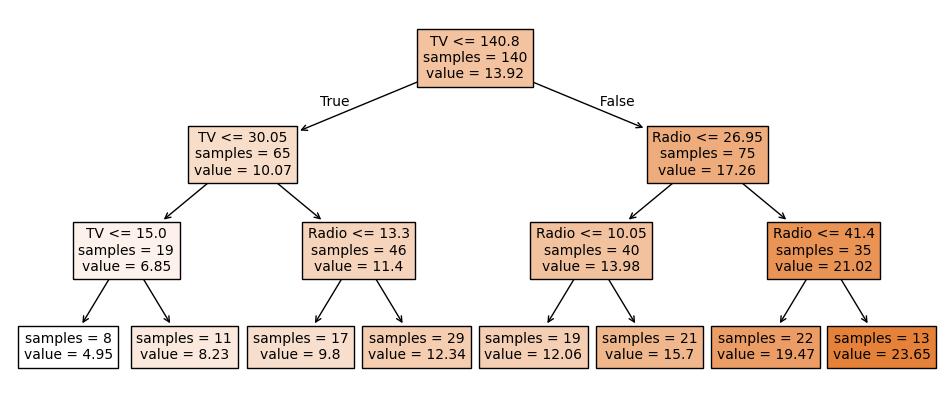

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
plot=plot_tree(
    decision_tree=modelo_ar,
    feature_names=datos.drop(columns="Sales").columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax
)

In [ ]:
texto_modelo=export_text(
    decision_tree=modelo_ar,
    feature_names=list(datos.drop(columns="Sales").columns)
)
print(texto_modelo)

|--- TV <= 140.80
|   |--- TV <= 30.05
|   |   |--- TV <= 15.00
|   |   |   |--- value: [4.95]
|   |   |--- TV >  15.00
|   |   |   |--- value: [8.23]
|   |--- TV >  30.05
|   |   |--- Radio <= 13.30
|   |   |   |--- value: [9.80]
|   |   |--- Radio >  13.30
|   |   |   |--- value: [12.34]
|--- TV >  140.80
|   |--- Radio <= 26.95
|   |   |--- Radio <= 10.05
|   |   |   |--- value: [12.06]
|   |   |--- Radio >  10.05
|   |   |   |--- value: [15.70]
|   |--- Radio >  26.95
|   |   |--- Radio <= 41.40
|   |   |   |--- value: [19.47]
|   |   |--- Radio >  41.40
|   |   |   |--- value: [23.65]



##4.3 Predicciones

La importancia de cada predictor en el modelo se calcula como la reducción total (normalizada) en el criterio de división. En este caso, el mse que consigue el predictor en las divisiones

In [ ]:
importancia_predictores=pd.DataFrame(
    {
        "predictor": datos.drop(columns="Sales").columns,
        "importancia":modelo_ar.feature_importances_
    }
)

In [ ]:
importancia_predictores.sort_values(by="importancia", ascending=False)

,predictor,importancia
0,TV,0.626264
1,Radio,0.373736
2,Newspaper,0.000000
3,Web,0.000000


In [ ]:
from sklearn.datasets import load_iris
from sklearn import tree
iris = load_iris()
from graphviz import Source
from IPython.display import Image, display
import numpy as np

In [ ]:
print("Features name - ", iris.feature_names)
print(iris.target)
print("Flor setosa: ", iris.data[0])
print("Flor versicolor", iris.data[50])
print("Flor virginica", iris.data[100])

Features name -  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Flor setosa:  [5.1 3.5 1.4 0.2]
Flor versicolor [7.  3.2 4.7 1.4]
Flor virginica [6.3 3.3 6.  2.5]


In [ ]:
test_indices = [0,1,50,51,100,101]

train_tangent = np.delete(iris.target, test_indices)
train_data= np.delete(iris.data, test_indices, axis=0)

test_tangent = iris.target[test_indices]
test_data = iris.data[test_indices]

In [ ]:
dtClassifier = tree.DecisionTreeClassifier(random_state=2022)
dtClassifier.fit(train_data, train_tangent)

DecisionTreeClassifier(random_state=2022)

In [ ]:
predicted_target=dtClassifier.predict(test_data)
print("\n*******************Resultados****************")
for p in range(len(test_indices)):
  print(f"Test Row {test_indices[p]} pertenece a la clase {predicted_target[p]}")


*******************Resultados****************
Test Row 0 pertenece a la clase 0
Test Row 1 pertenece a la clase 0
Test Row 50 pertenece a la clase 1
Test Row 51 pertenece a la clase 1
Test Row 100 pertenece a la clase 2
Test Row 101 pertenece a la clase 2


In [ ]:
iris2=pd.DataFrame(data=np.c_[iris["data"],iris["target"]],
                   columns=iris["feature_names"]+["target"])
iris2.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
94,5.6,2.7,4.2,1.3,1.0
142,5.8,2.7,5.1,1.9,2.0
93,5.0,2.3,3.3,1.0,1.0
97,6.2,2.9,4.3,1.3,1.0
127,6.1,3.0,4.9,1.8,2.0


In [ ]:
print(f"Tamaño del dataframe: {iris2.shape}")

Tamaño del dataframe: (150, 5)


In [ ]:
X_train, X_test,Y_train, Y_test = train_test_split(iris2.drop(columns="target"),iris2["target"],train_size=0.7,random_state=1289)

In [ ]:
modelo_flor=DecisionTreeRegressor(random_state=2022)

In [ ]:
modelo_flor.fit(X_train,Y_train)

DecisionTreeRegressor(random_state=2022)

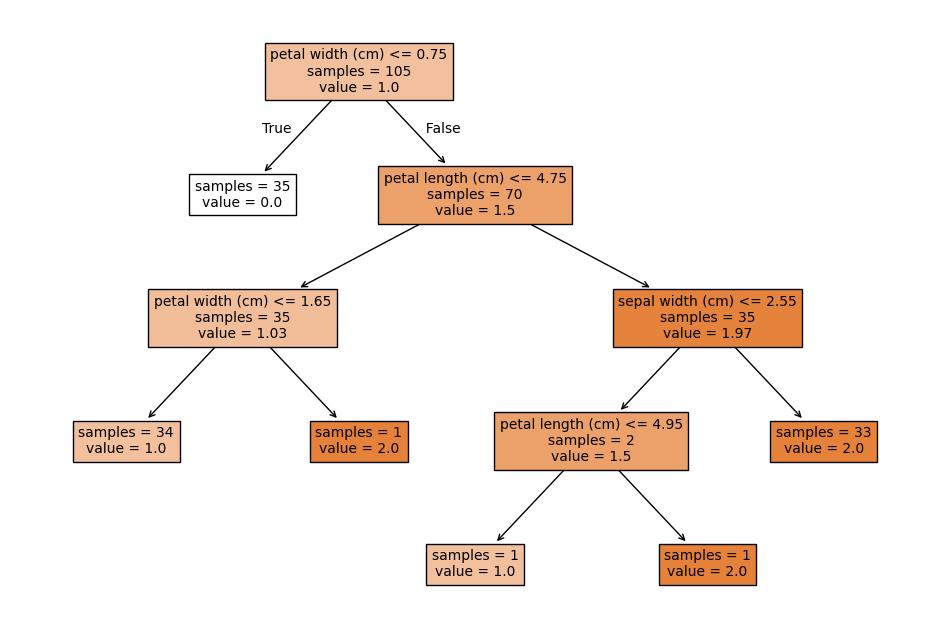

In [ ]:
fig,ax=plt.subplots(figsize=(12,8))
plot=plot_tree(
    decision_tree=modelo_flor,
    feature_names=iris2.drop(columns=["target"]).columns,
    filled=True,
    impurity=False,
    fontsize=10,
    precision=2,
    ax=ax

)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [ ]:
pima=pd.read_csv(path+"/diabetes.csv")
pima.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
